In [1]:
import sys
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.interpolate import CubicSpline
from scipy.integrate import quad

sys.path.append('..')

from pseudoFrameWork.api import getAnyMOEX

plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['axes.facecolor'] = 'black'
plt.rcParams['figure.facecolor'] = 'black'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white' 
plt.rcParams['xtick.color'] = 'white'    
plt.rcParams['ytick.color'] = 'white'    
plt.rcParams['axes.grid'] = True

warnings.filterwarnings('ignore')

DAYS_IN_YEAR = 252
N_PATHS = int(5e+3)


In [2]:
imoex = await getAnyMOEX(
    api_method=r'/iss/history/engines/stock/markets/index/sessions/SNDX/securities/imoex.json',
    arguments={ 'from': '2022-07-01', 'till': '2026-02-28' },
    field='history',
    all=True
)

imoex = imoex[['TRADEDATE', 'CLOSE']].rename(columns={'TRADEDATE': 'date', 'CLOSE': 'close'})

ZCC = pd.read_html(r'https://www.cbr.ru/hd_base/zcyc_params/?UniDbQuery.Posted=True&UniDbQuery.From=01.07.2022&UniDbQuery.To=28.02.2026')[0]
ZCC = ZCC.T.reset_index(drop=True).T
ZCC = ZCC[[0, 4]].copy().rename(columns={0: 'date', 4: 'r'})

ZCC['r'] = ZCC['r'].astype(float) * 1e-4
ZCC['date'] = pd.to_datetime(ZCC['date'], dayfirst=True).dt.strftime('%Y-%m-%d')

imoex = imoex.merge(ZCC, on='date')


In [3]:
imoex['return'] = np.log( imoex['close'] ).diff()
imoex['closeLag'] = imoex['close'].shift(1)

imoex['bucket'] = pd.cut(imoex['closeLag'], bins=20)  
bucketVol = imoex.groupby('bucket')['return'].agg(lambda x: np.std(x) * np.sqrt(DAYS_IN_YEAR))
bucketCenter = imoex.groupby('bucket')['closeLag'].mean()
imoex.dropna(inplace=True)

imoex

,date,close,r,return,closeLag,bucket
1,2022-07-04,2204.66,0.0849,-0.000884,2206.61,"(2154.708, 2233.954]"
2,2022-07-05,2226.64,0.0851,0.009920,2204.66,"(2154.708, 2233.954]"
3,2022-07-06,2221.88,0.0844,-0.002140,2226.64,"(2154.708, 2233.954]"
4,2022-07-07,2226.65,0.0829,0.002145,2221.88,"(2154.708, 2233.954]"
5,2022-07-08,2222.51,0.0826,-0.001861,2226.65,"(2154.708, 2233.954]"
...,...,...,...,...,...,...
927,2026-02-20,2780.60,0.1419,0.002795,2772.84,"(2709.43, 2788.676]"
928,2026-02-24,2777.35,0.1422,-0.001169,2780.60,"(2709.43, 2788.676]"
929,2026-02-25,2795.39,0.1418,0.006474,2777.35,"(2709.43, 2788.676]"
930,2026-02-26,2785.58,0.1429,-0.003516,2795.39,"(2788.676, 2867.922]"


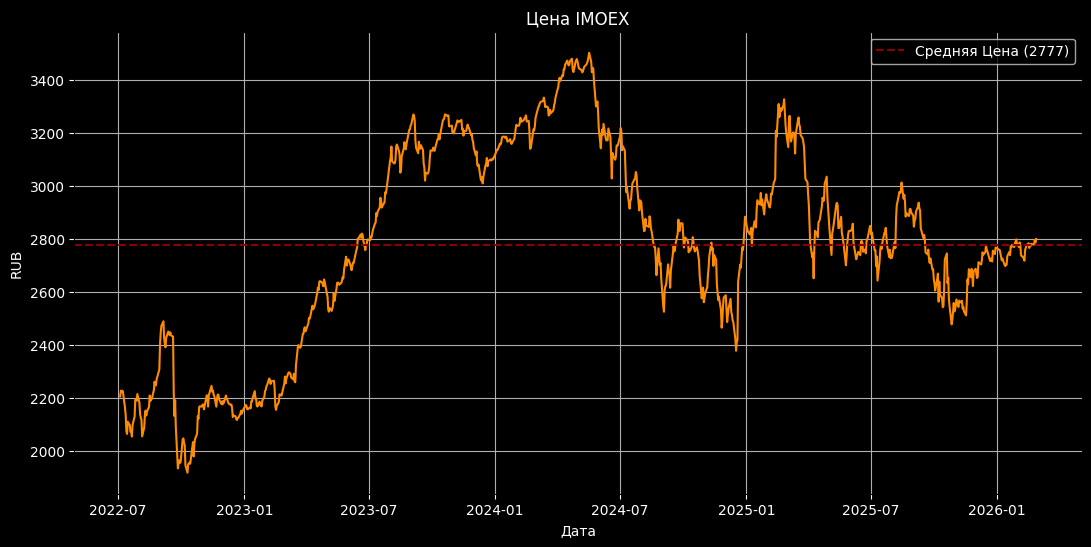

In [4]:
plt.plot(pd.to_datetime(imoex['date']), imoex['close'], color='darkorange')
plt.axhline(imoex['close'].mean(), linestyle='--', label=f'Средняя Цена ({imoex["close"].mean():.0f})', color='darkred')
plt.title('Цена IMOEX')
plt.xlabel('Дата')
plt.ylabel('RUB')
plt.legend()
plt.show()

In [5]:
def CEVLogLikelihood(params, prices, returns, dt=1 / DAYS_IN_YEAR):
    sigma, beta = params
    r = returns
    
    var = sigma ** 2 * prices ** (2 * beta - 2) 
    
    ll = -0.5 * np.sum(np.log(2 * np.pi * var) + r ** 2 / var)

    return -ll  


bounds = [(0.01, 2), (0.1, 10)]

result = minimize(
    CEVLogLikelihood, 
    [0.3, 0.5], 
    method='L-BFGS-B', 
    args=(imoex['closeLag'].values, imoex['return'].values),
    bounds=bounds
)

sigma, beta = result.x


In [6]:
result

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -2728.5184910758726
        x: [ 1.988e+00  3.638e-01]
      nit: 34
      jac: [-1.780e+00 -8.845e-01]
     nfev: 132
     njev: 44
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>

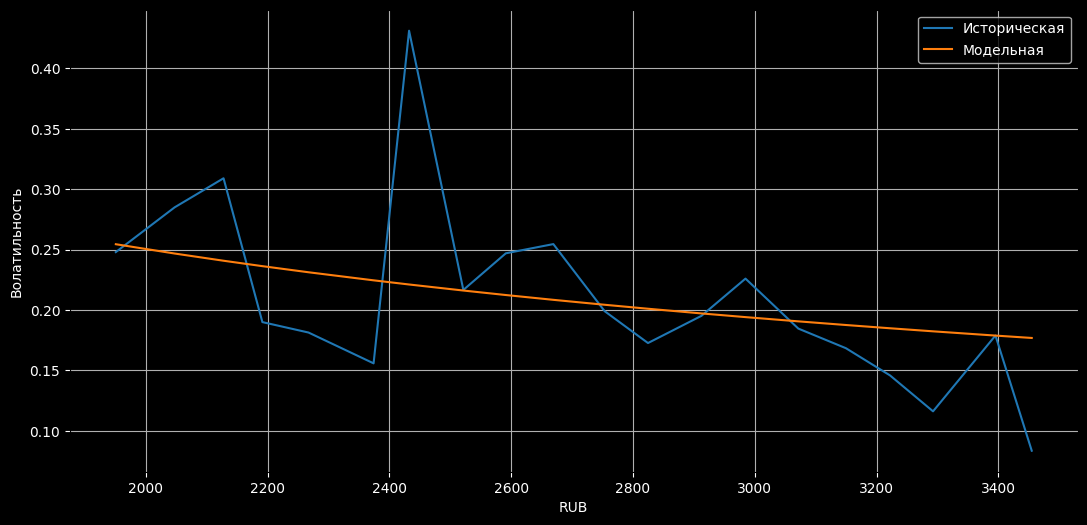

In [7]:
plt.plot(bucketCenter, bucketVol, label='Историческая')
plt.plot(bucketCenter, [ sigma * np.power(S_0, beta - 1) * np.sqrt(DAYS_IN_YEAR) for S_0 in bucketCenter ], label='Модельная')
plt.xlabel('RUB')
plt.ylabel('Волатильность')
plt.legend()
plt.show()

In [8]:
morality = pd.read_excel('morality2023.xlsx')
morality = morality[['sex', 'age', 'indicator_value']].copy()

morality['age'] = morality['age'].str.findall(r'-?\d+\.?\d*')
morality['age'] = morality['age'].apply(lambda x: int(x[0]) if len(x) == 1 else (int(x[0]) - int(x[1])) / 2)
morality.loc[morality['age'] == 85, 'age'] = 87

morality['indicator_value'] /= 1e+5
morality['hazard'] = - np.log(1 - morality['indicator_value'])

morality['sex'] = morality['sex'].apply(lambda x: { 'Женщины': 'f', 'Мужчины': 'm' }.get(x))

maleMu, femaleMu = (
    lambda x: CubicSpline(morality[morality['sex'] == 'm']['age'], morality[morality['sex'] == 'm']['hazard'])(x).item() if x.shape == () else CubicSpline(morality[morality['sex'] == 'm']['age'], morality[morality['sex'] == 'm']['hazard'])(x),
    lambda x: CubicSpline(morality[morality['sex'] == 'f']['age'], morality[morality['sex'] == 'f']['hazard'])(x).item() if x.shape == () else CubicSpline(morality[morality['sex'] == 'f']['age'], morality[morality['sex'] == 'f']['hazard'])(x),
)

morality


,sex,age,indicator_value,hazard
0,m,0.0,0.004493,0.004503
1,m,2.5,0.000312,0.000312
2,m,7.0,0.000177,0.000177
3,m,12.0,0.000246,0.000246
4,m,17.0,0.000738,0.000738
5,m,22.0,0.002020,0.002022
6,m,27.0,0.003102,0.003107
7,m,32.0,0.004407,0.004417
8,m,37.0,0.006112,0.006131
9,m,42.0,0.008674,0.008712


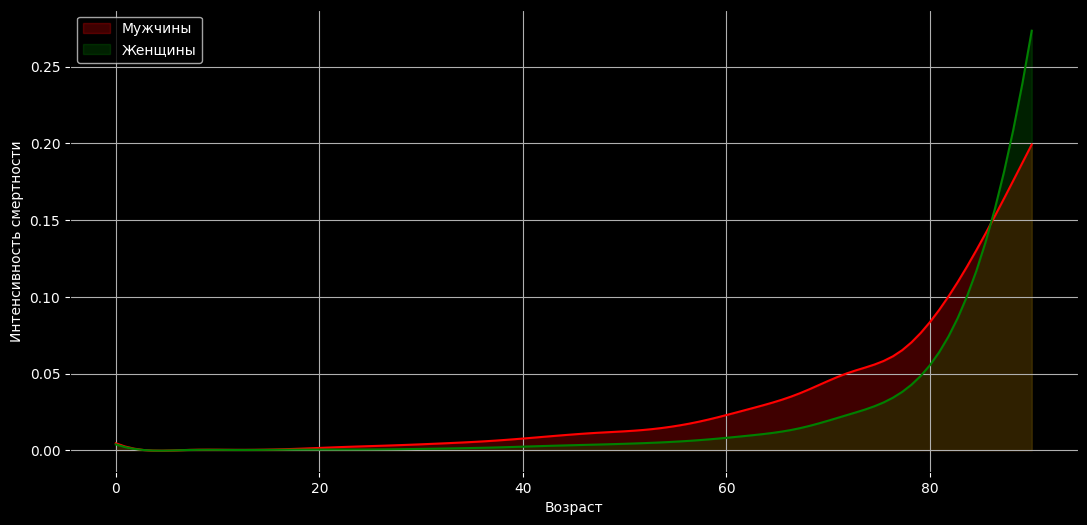

In [9]:
_age = np.linspace(0, 90, 100)

maleCurve, femaleCurve = [ maleMu(x) for x in _age ], [ femaleMu(x) for x in _age ]

plt.plot(_age, maleCurve, color='red')
plt.fill_between(_age, maleCurve, np.zeros_like(maleCurve), color='red', alpha=0.25, label='Мужчины')

plt.plot(_age, femaleCurve, color='green')
plt.fill_between(_age, femaleCurve, np.zeros_like(femaleCurve), color='green', alpha=0.25, label='Женщины')

plt.xlabel('Возраст')
plt.ylabel('Интенсивность смертности')

plt.legend()
plt.show()


In [10]:
def _simulatePaths(
    S_0: float,
    r: float,
    T: float,
    sigma: float = sigma,
    beta: float = beta,
    dt: float = 1 / DAYS_IN_YEAR,
    nPaths: int = N_PATHS

) -> np.ndarray:
    
    Z = np.random.normal(size=(nPaths // 2, int(T / dt)))
    Z = np.concatenate([Z, -Z], axis=0)
    Z[:, 0] = S_0

    for i in range( 1, int(T / dt) ):
        vola = sigma * np.power(Z[:, i - 1], beta - 1) * np.sqrt(DAYS_IN_YEAR)

        Z[:, i] = Z[:, i - 1] * np.exp(
            (r - 0.5 * np.square(vola)) * dt + vola * np.sqrt(dt) * Z[:, i]
        )
    
    return Z


def _simulateDeathTime(
    T: float,
    age: float,
    mu: CubicSpline,
    dt: float = 1 / DAYS_IN_YEAR,
    nPaths: int = N_PATHS

) -> np.ndarray:
    
    probs = mu( age + np.arange(int(T / dt)) * dt)   # hazard
    probs = 1 - np.exp(- probs * dt)                 # daily probs

    deathProbs = np.zeros(int(T / dt) + 1)           # survival
    deathProbs[0] = 1.0
    np.cumprod(1 - probs, out=deathProbs[1:])

    deathProbs = 1 - deathProbs                      # death prob

    U = np.random.uniform(size=nPaths)

    idx = np.searchsorted(deathProbs, U, side='left')
    idx = np.clip(idx, 0, int(T / dt))

    times = np.minimum((idx + 0.5) * dt, T)
    
    return idx, times
    

def pvCalc(
    S_0: float,
    r: float,
    T: float,
    age: float,
    mu: CubicSpline,
    sigma: float = sigma,
    alpha: float = 0.75,
    notional: float = 1e+5,
    beta: float = beta,
    dt: float = 1 / DAYS_IN_YEAR,
    nPaths: int = N_PATHS,
    qnt: int | None = None

) -> float:
    
    G = notional * (1 - alpha)
    
    if qnt is None: qnt = np.floor(notional * alpha / S_0)
    
    paths = _simulatePaths(S_0, r, T, sigma, beta, dt, nPaths)
    idx, times = _simulateDeathTime(T - dt, age, mu, dt, nPaths)

    return np.nanmean( np.exp(- r * times) * (paths[ np.arange(nPaths), idx ] * qnt + G) )


def irrCalc(
    S_0: float,
    r: float,
    T: float,
    age: float,
    mu: CubicSpline,
    sigma: float = sigma,
    alpha: float = 0.75,
    notional: float = 1e+5,
    beta: float = beta,
    dt: float = 1 / DAYS_IN_YEAR,
    nPaths: int = N_PATHS,
    qnt: int | None = None

) -> np.ndarray:
    
    G = notional * (1 - alpha)
    
    if qnt is None: qnt = np.floor(notional * alpha / S_0)
    
    paths = _simulatePaths(S_0, r, T, sigma, beta, dt, nPaths)
    idx, times = _simulateDeathTime(T - dt, age, mu, dt, nPaths)

    irr = np.power( (paths[ np.arange(nPaths), idx ] * qnt + G) / notional, 1 / times ) - 1

    return irr



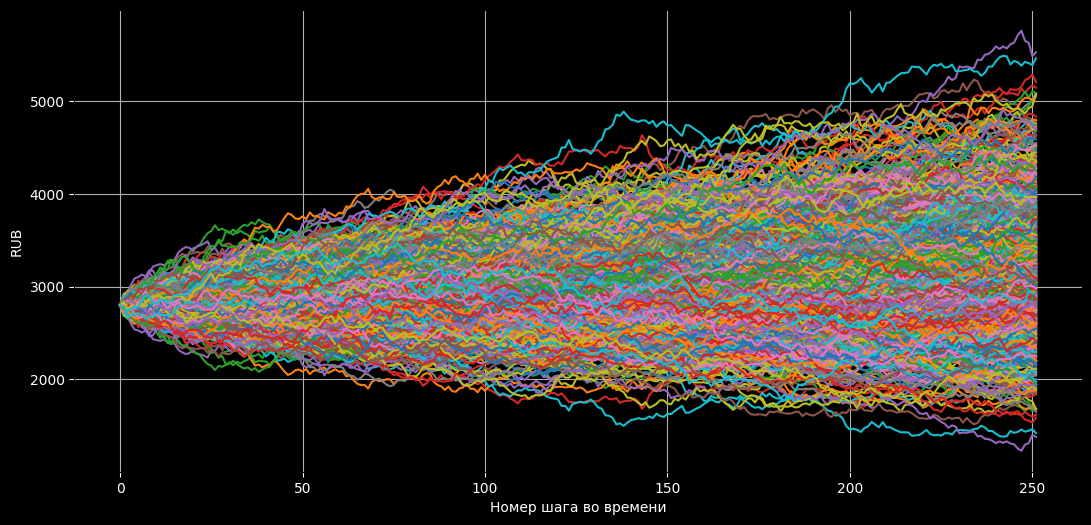

In [11]:
z = _simulatePaths(2799.14, 0.1424, 1, nPaths=1000)

plt.plot(z.T)
plt.xlabel('Номер шага во времени')
plt.ylabel('RUB')
plt.show()

In [49]:
pvCalc(3130.23, 0.129, 15, 65, femaleMu)  

np.float64(77291.81868757606)

In [60]:
irr = irrCalc(2172.68, 0.07010000000000001, 1, 25, femaleMu, nPaths=int(5e+4), alpha=0.95)

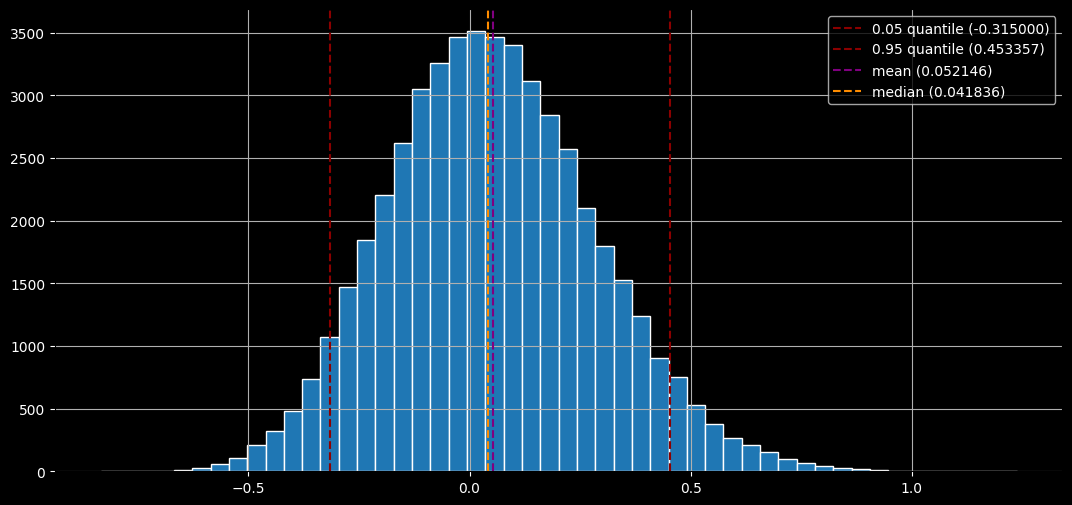

In [61]:
_q = 0.05

plt.hist(irr, bins=50, edgecolor='white')
plt.axvline( np.nanquantile(irr, _q), color='darkred', linestyle='--', label=f'{_q} quantile ({np.nanquantile(irr, _q):4f})')
plt.axvline( np.nanquantile(irr, 1 - _q), color='darkred', linestyle='--', label=f'{1 -_q} quantile ({np.nanquantile(irr, 1 - _q):4f})')
plt.axvline( np.nanmean(irr), color='purple', linestyle='--', label=f'mean ({np.nanmean(irr):4f})')
plt.axvline( np.nanmedian(irr), color='darkorange', linestyle='--', label=f'median ({np.nanmedian(irr):4f})')

plt.legend()
plt.show()